In [61]:
import os
import pandas as pd
import numpy as np
import pathlib
from copy import deepcopy

In [62]:
methods = ["fam-sim", "rnadist", "samples", "herarchical_cluster"]
fams = os.listdir("fam-sim/1_epoch")
epochs = [f"{i}_epoch" for i in range(1, 11)]
dist = [f"dist_{i}" for i in [100, 200, 400]]

print(fams)
print(epochs)
print(dist)

['23s', 'telomerase', '16s', '5s', 'grp1', 'srp', 'RNaseP', 'tmRNA', 'tRNA']
['1_epoch', '2_epoch', '3_epoch', '4_epoch', '5_epoch', '6_epoch', '7_epoch', '8_epoch', '9_epoch', '10_epoch']
['dist_100', 'dist_200', 'dist_400']


In [63]:
metrics = {}
template = {"train": pd.DataFrame(), "test": pd.DataFrame()}
for m in methods:
    if m == "fam-sim":
        metrics[m] = deepcopy(template)
    else:
        metrics[m] = {}
        for d in dist:
            metrics[m][d] = deepcopy(template)

In [64]:
def log_and_concat(df, path, epoch, fam):
    new = pd.read_csv(path)
    new["epoch"] = epoch
    new["fam"] = fam
    return pd.concat([df, new], ignore_index=True)

In [65]:
# Esta celda acumula los resultados, si se corre 2 veces quedan duplicados.

for m in methods:
    for f in fams:
        for i, e in enumerate(epochs):
            if m == "fam-sim":
                PATH = pathlib.Path(f"{m}/{e}/{f}/")
                train = PATH / "train_log.csv"
                test = PATH / "test.csv"
                metrics[m]["train"] = log_and_concat(metrics[m]["train"], train, i, f)
                metrics[m]["test"] = log_and_concat(metrics[m]["test"], test, i, f)

            else:
                for d in dist:
                    PATH = pathlib.Path(f"{m}/{d}/{e}/{f}/")
                    train = PATH / "train_log.csv"
                    test = PATH / "test.csv"
                    metrics[m][d]["train"] = log_and_concat(
                        metrics[m][d]["train"], train, i, f
                    )
                    metrics[m][d]["test"] = log_and_concat(
                        metrics[m][d]["test"], test, i, f
                    )

In [66]:
df = metrics["fam-sim"]["test"]
df
# Vamos a hacer estadisticas de mejores resultados por familia y epoch, considerando media entre todas las familas para una epoca y la mejor epoca para cada familia.

,f1,f1_post,loss,epoch,fam
0,0.375,0.423,0.029,0,23s
1,0.379,0.384,0.045,1,23s
2,0.213,0.210,0.084,2,23s
3,0.329,0.327,0.058,3,23s
4,0.257,0.246,0.095,4,23s
...,...,...,...,...,...
85,0.624,0.632,0.129,5,tRNA
86,0.621,0.627,0.133,6,tRNA
87,0.630,0.639,0.149,7,tRNA
88,0.570,0.576,0.222,8,tRNA


In [67]:
df.drop_duplicates().query('fam=="telomerase"')

,f1,f1_post,loss,epoch,fam
10,0.223,0.195,0.026,0,telomerase
11,0.235,0.209,0.028,1,telomerase
12,0.130,0.112,0.040,2,telomerase
13,0.158,0.136,0.043,3,telomerase
14,0.183,0.172,0.037,4,telomerase
15,0.188,0.174,0.045,5,telomerase
16,0.179,0.150,0.045,6,telomerase
17,0.157,0.135,0.045,7,telomerase
18,0.149,0.126,0.066,8,telomerase
19,0.170,0.145,0.047,9,telomerase


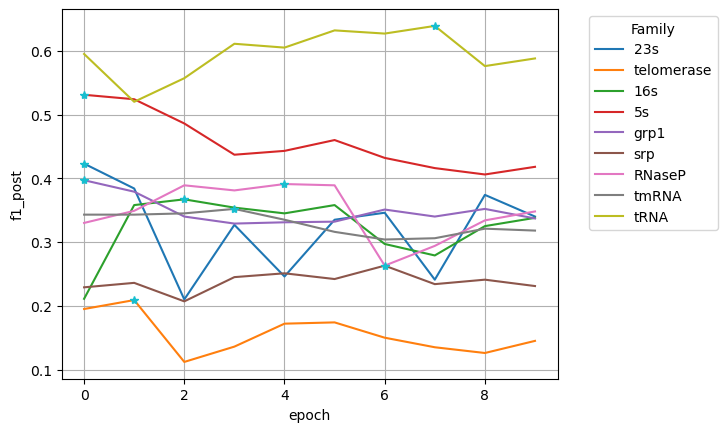

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt


df = metrics["fam-sim"]["test"].copy()
df.set_index(["epoch"], inplace=True)

f = sns.lineplot(
    data=df,
    x="epoch",
    y="f1_post",
    hue="fam",
    # legend,
)
max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
ids = [df.query("fam == @f")["f1_post"].idxmax() for f in fams]
plt.plot(
    ids,
    max,
    "*",
    # color=colors,
)

plt.grid()
plt.legend(title="Family", bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [69]:
def plot_f1_test(data, y, ax):

    df = data.copy()
    f = sns.lineplot(
        data=df,
        x="epoch",
        y=y,
        hue="fam",
        ax=ax,
    )

    max = [np.max(df.query("fam == @f")[y]) for f in fams]
    ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
    ax.plot(
        ids,
        max,
        "*",
    )
    ax.grid()
    ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
    return ax
    # plt.show()

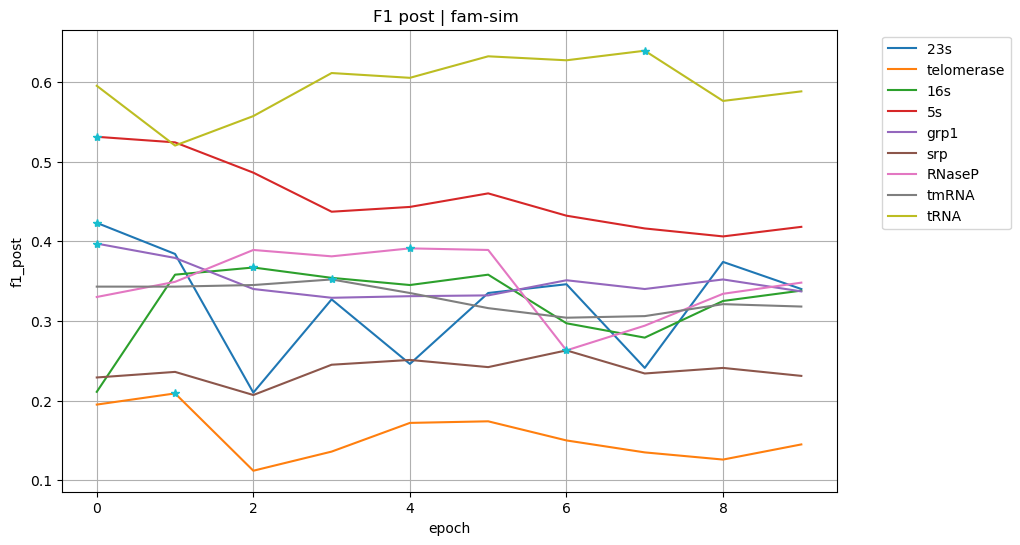

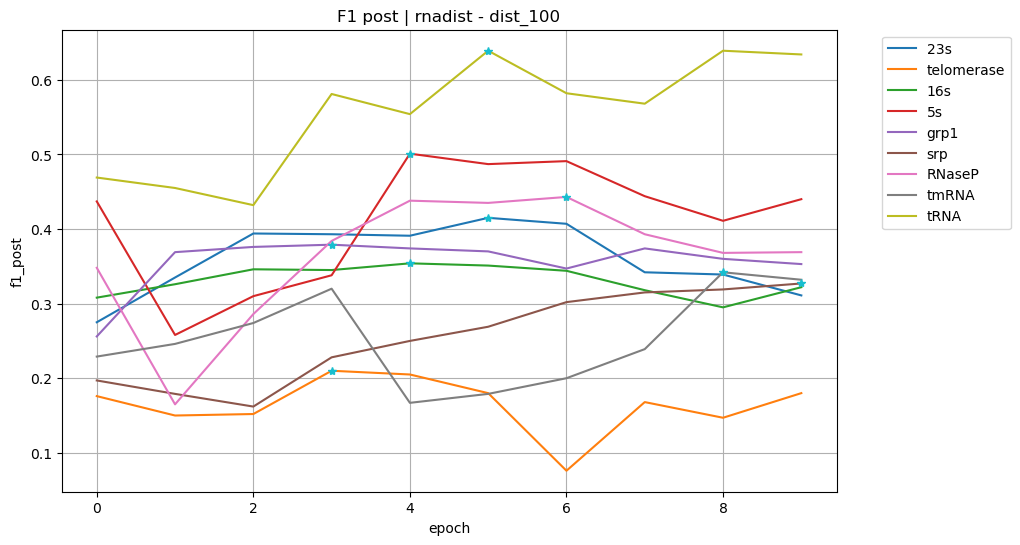

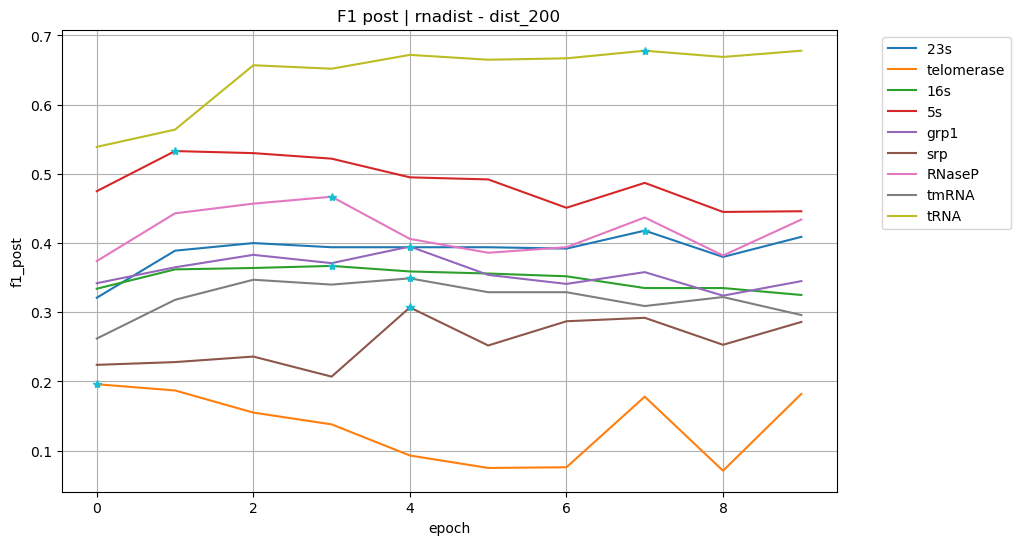

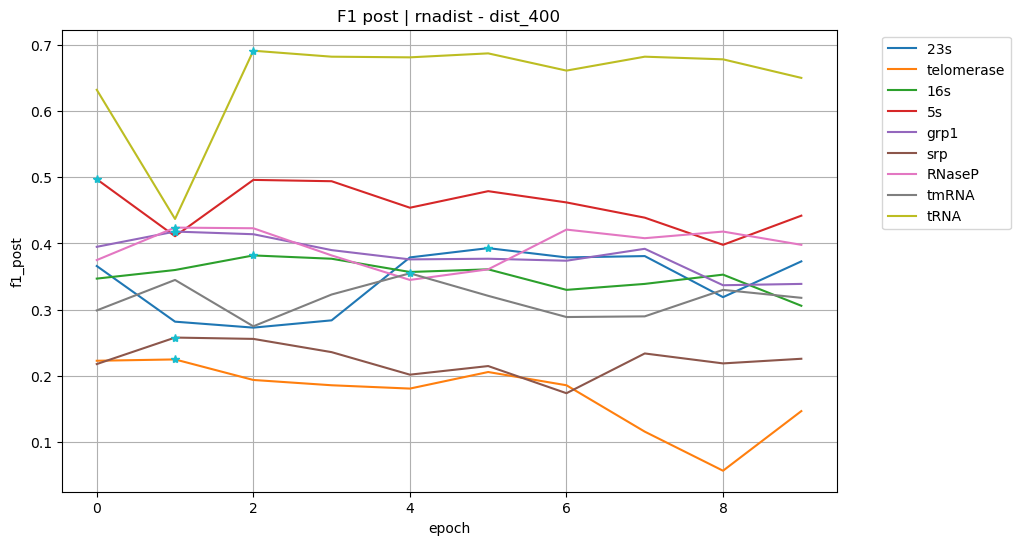

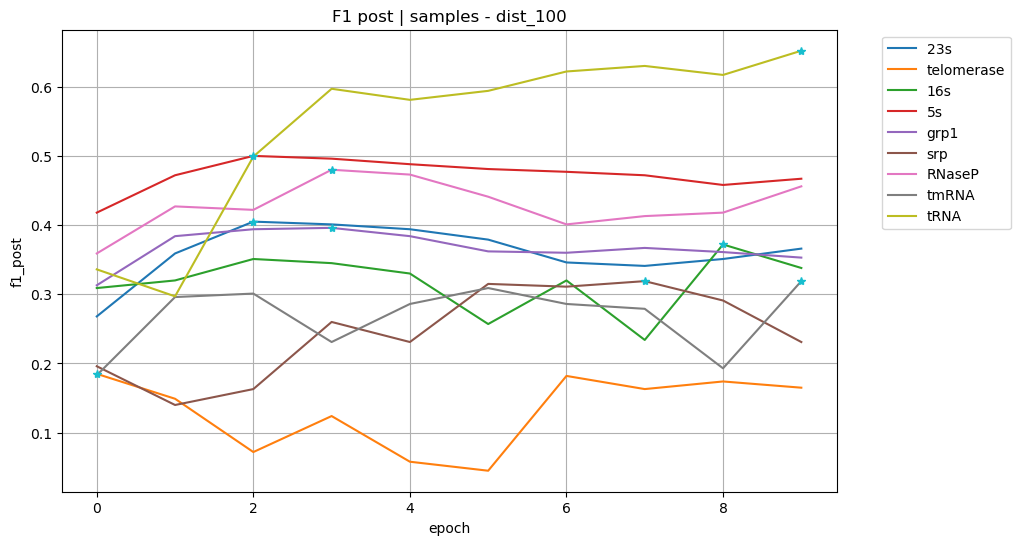

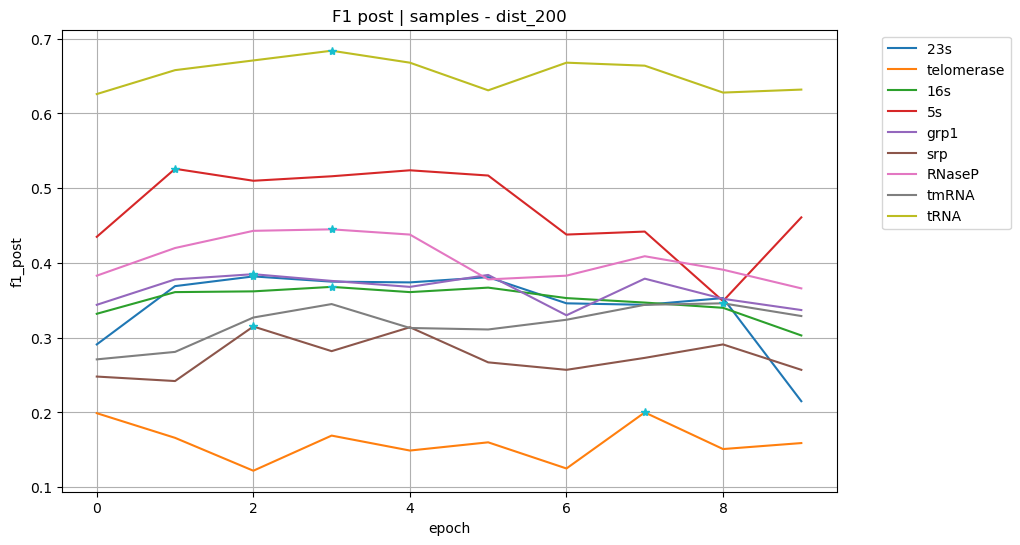

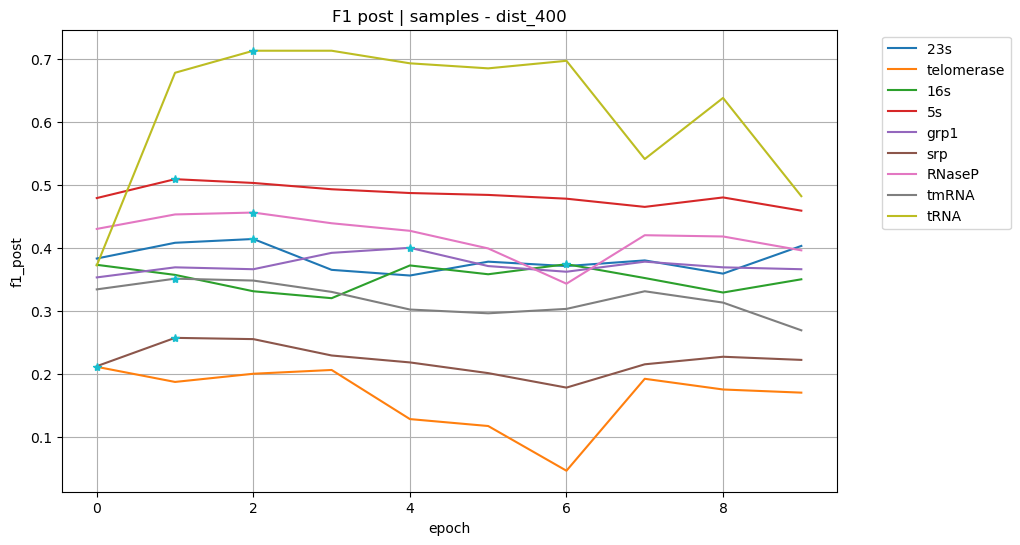

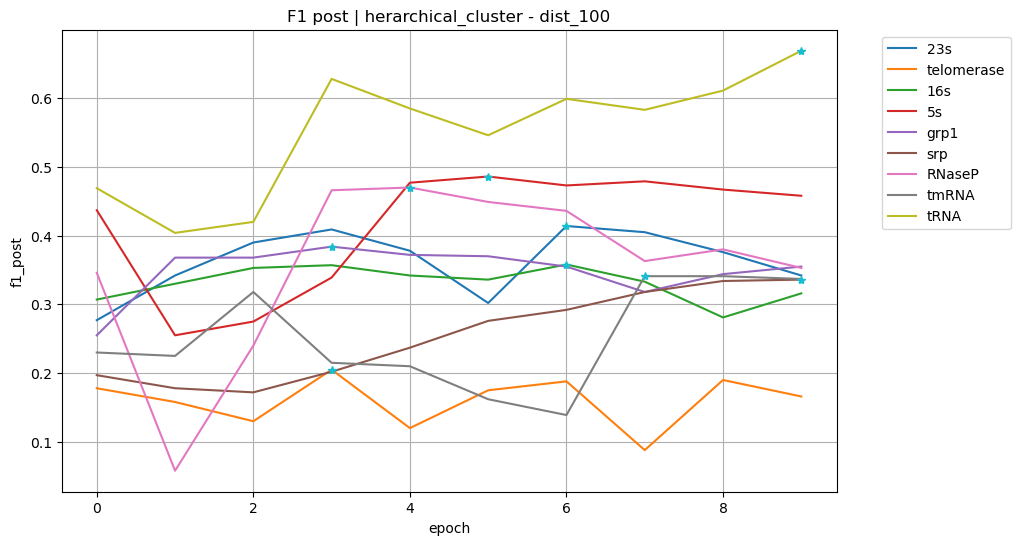

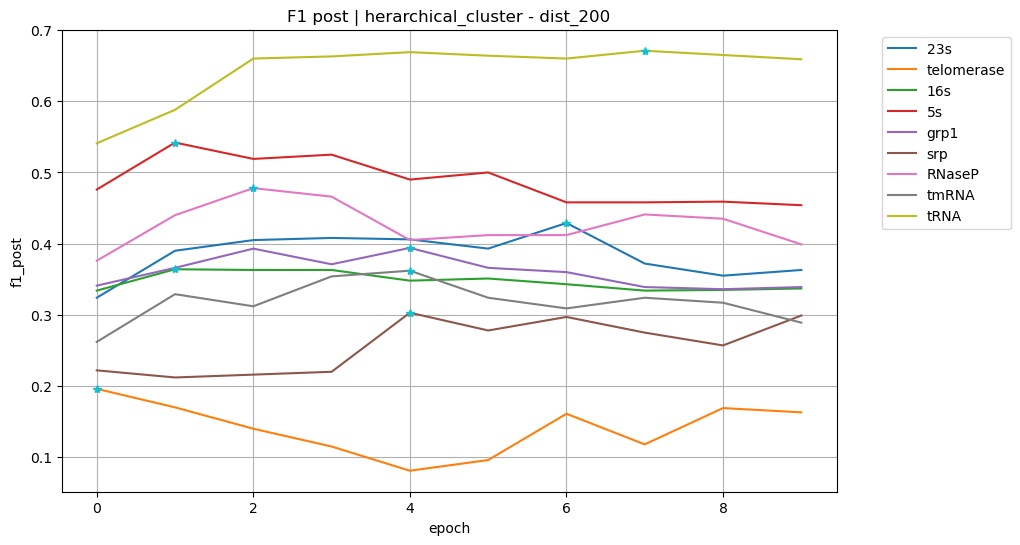

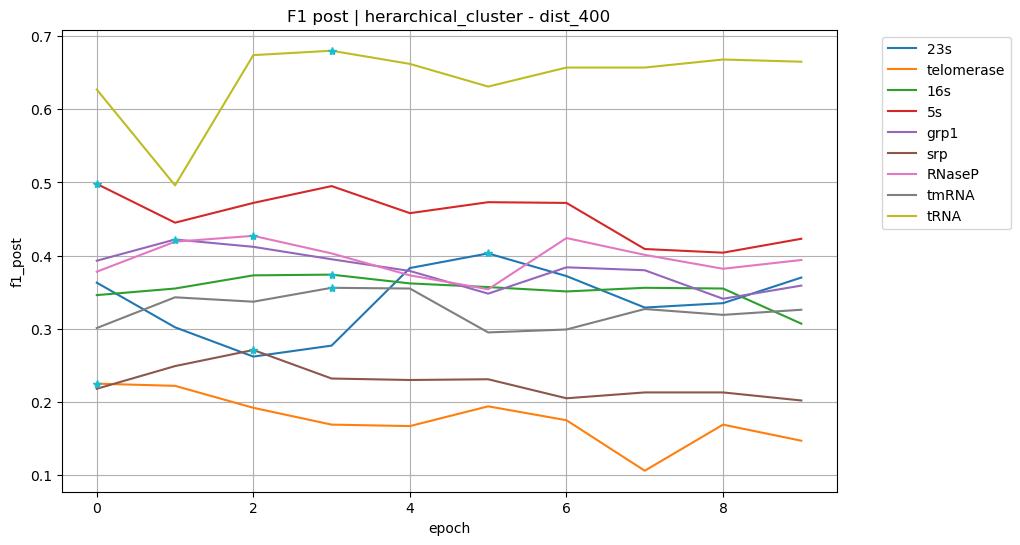

In [70]:
y = "f1_post"
for m in methods:
    if m == "fam-sim":
        plt.figure(figsize=(10, 6))
        ax1 = plt.subplot(1, 1, 1)
        ax1 = plot_f1_test(metrics[m]["test"], y, ax1)
        ax1.set_title(f"F1 post | {m} ")
        plt.show()
    else:
        for d in dist:
            plt.figure(figsize=(10, 6))
            ax1 = plt.subplot(1, 1, 1)
            ax1 = plot_f1_test(metrics[m][d]["test"], y, ax1)
            ax1.set_title(f"F1 post | {m} - {d}")
            plt.show()

In [71]:
# y = "valid_f1_post"
# for m in methods:
#     if m == "fam-sim":
#         plt.figure(figsize=(10, 6))
#         ax1 = plt.subplot(1, 1, 1)
#         ax1 = plot_f1_test(metrics[m]["train"], y, ax1)
#         ax1.set_title(f"F1 post | {m} ")
#         plt.show()
#     else:
#         for d in dist:
#             plt.figure(figsize=(10, 6))
#             ax1 = plt.subplot(1, 1, 1)
#             ax1 = plot_f1_test(metrics[m][d]["train"], y, ax1)
#             ax1.set_title(f"F1 post | {m} - {d}")
#             plt.show()

In [72]:
df = metrics[m][d]["test"]

In [73]:
means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
best = np.max(means)
best_epoch = means.index(best)
print(best_epoch, best)

2 0.38


In [74]:
print("Mejor promedio por epoca para cada metodo")
for m in methods:
    if m == "fam-sim":
        print(f"Method: {m}")
        df = metrics[m]["test"]
        means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
        best = np.max(means)
        best_epoch = means.index(best)
        print(best_epoch, round(best, 3))

    else:
        for d in dist:

            df = metrics[m][d]["test"]
            print(f"Method: {m}| Distance: {d}")
            means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
            best = np.max(means)
            best_epoch = means.index(best)
            print(best_epoch, round(best, 3))

Mejor promedio por epoca para cada metodo
Method: fam-sim
1 0.367
Method: rnadist| Distance: dist_100
5 0.369
Method: rnadist| Distance: dist_200
2 0.392
Method: rnadist| Distance: dist_400
2 0.378
Method: samples| Distance: dist_100
9 0.372
Method: samples| Distance: dist_200
3 0.396
Method: samples| Distance: dist_400
2 0.398
Method: herarchical_cluster| Distance: dist_100
9 0.37
Method: herarchical_cluster| Distance: dist_200
2 0.387
Method: herarchical_cluster| Distance: dist_400
2 0.38


In [81]:
print("mejor valor y epoca por familia y metodo")
for m in methods:
    if m == "fam-sim":
        print(12 * "#")
        print(f"Method: {m}")
        print(12 * "#")
        df = metrics[m]["test"]
        max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
        ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
        for i, f in enumerate(fams):
            print(f"{f:<10}: Epoch {ids[i]}, F1 post max| {max[i]}")
        print("Promedio: ", round(np.mean(max), 3))
    else:
        for d in dist:
            df = metrics[m][d]["test"]
            print(12 * "#")
            print(f"Method: {m}| Distance: {d}")
            print(12 * "#")
            max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
            ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
            for i, f in enumerate(fams):
                print(f"{f:<10}: Epoch {ids[i]}, F1 post max| {round(max[i], 3)}")
            print("Promedio: ", round(np.mean(max), 3))

mejor valor y epoca por familia y metodo
############
Method: fam-sim
############
23s       : Epoch 0, F1 post max| 0.423
telomerase: Epoch 1, F1 post max| 0.209
16s       : Epoch 2, F1 post max| 0.367
5s        : Epoch 0, F1 post max| 0.531
grp1      : Epoch 0, F1 post max| 0.397
srp       : Epoch 6, F1 post max| 0.263
RNaseP    : Epoch 4, F1 post max| 0.391
tmRNA     : Epoch 3, F1 post max| 0.352
tRNA      : Epoch 7, F1 post max| 0.639
Promedio:  0.397
############
Method: rnadist| Distance: dist_100
############
23s       : Epoch 5, F1 post max| 0.415
telomerase: Epoch 3, F1 post max| 0.21
16s       : Epoch 4, F1 post max| 0.354
5s        : Epoch 4, F1 post max| 0.501
grp1      : Epoch 3, F1 post max| 0.379
srp       : Epoch 9, F1 post max| 0.327
RNaseP    : Epoch 6, F1 post max| 0.443
tmRNA     : Epoch 8, F1 post max| 0.342
tRNA      : Epoch 5, F1 post max| 0.639
Promedio:  0.401
############
Method: rnadist| Distance: dist_200
############
23s       : Epoch 7, F1 post max| 0.418
